# Exploratory Data Analysis — Alberta Electricity Price Spikes

In [9]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from shared.data_prep import load_data, split_data, TARGET

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 4)})
sns.set_theme(style="whitegrid")

In [10]:
df = load_data()
train, val, test = split_data(df)
print(f"Full dataset : {df.shape}")
print(f"Train        : {train.shape}  {train['datetime'].min().date()} \u2192 {train['datetime'].max().date()}")
print(f"Validation   : {val.shape}   {val['datetime'].min().date()} \u2192 {val['datetime'].max().date()}")
print(f"Test         : {test.shape}   {test['datetime'].min().date()} \u2192 {test['datetime'].max().date()}")

Full dataset : (48839, 117)
Train        : (33672, 117)  2020-01-02 → 2023-11-05
Validation   : (9624, 117)   2023-11-06 → 2024-12-11
Test         : (5543, 117)   2024-12-12 → 2025-07-30


## 1. Dataset Overview

In [11]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes.value_counts())
print("\nMissing values (top 10):\n", df.isnull().sum().sort_values(ascending=False).head(10))
print("\nTarget distribution:")
print(df[TARGET].value_counts())
print(f"\nSpike rate: {df[TARGET].mean():.2%}")

Shape: (48839, 117)

Dtypes:
 float64           78
int64             38
datetime64[us]     1
Name: count, dtype: int64

Missing values (top 10):
 datetime                0
ACTUAL_POOL_PRICE       0
ACTUAL_AIL              0
coal_total              0
dual_fuel_total         0
energy_storage_total    0
gas_total               0
hydro_total             0
other_total             0
solar_total             0
dtype: int64

Target distribution:
spike_lead_1
0    43981
1     4858
Name: count, dtype: int64

Spike rate: 9.95%


## 2. Pool Price Time Series

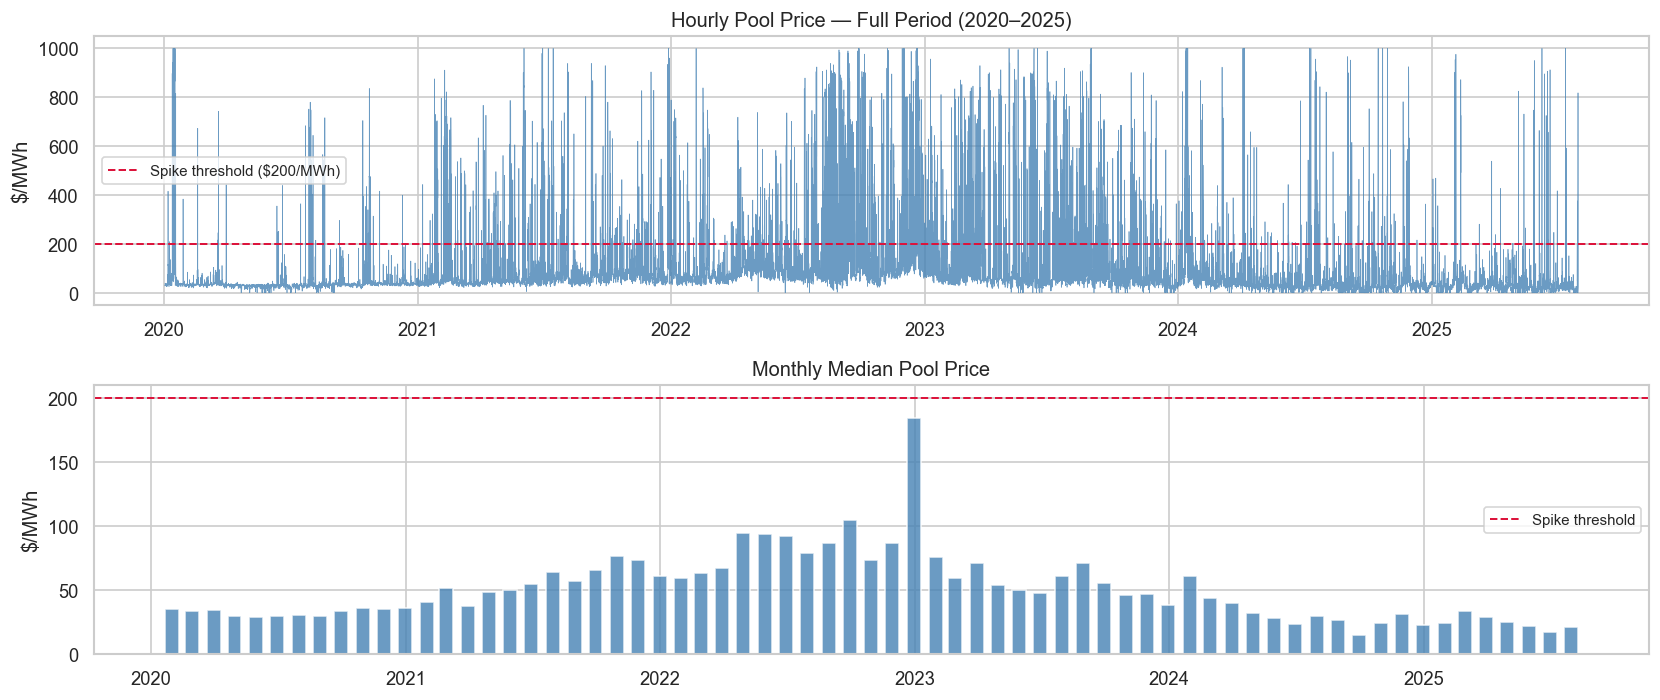

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

# Full period
axes[0].plot(df["datetime"], df["ACTUAL_POOL_PRICE"], lw=0.4, color="steelblue", alpha=0.8)
axes[0].axhline(200, color="crimson", ls="--", lw=1.2, label="Spike threshold ($200/MWh)")
axes[0].set_title("Hourly Pool Price \u2014 Full Period (2020\u20132025)")
axes[0].set_ylabel("$/MWh")
axes[0].legend(fontsize=9)

# Monthly median
monthly = df.set_index("datetime")["ACTUAL_POOL_PRICE"].resample("ME").median()
axes[1].bar(monthly.index, monthly.values, width=20, color="steelblue", alpha=0.8)
axes[1].axhline(200, color="crimson", ls="--", lw=1.2, label="Spike threshold")
axes[1].set_title("Monthly Median Pool Price")
axes[1].set_ylabel("$/MWh")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 3. Price Distribution & Spike Tail

C:\Users\Carolmon\AppData\Local\Temp\ipykernel_22680\3641047777.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="label", y="ACTUAL_POOL_PRICE", ax=axes[1],


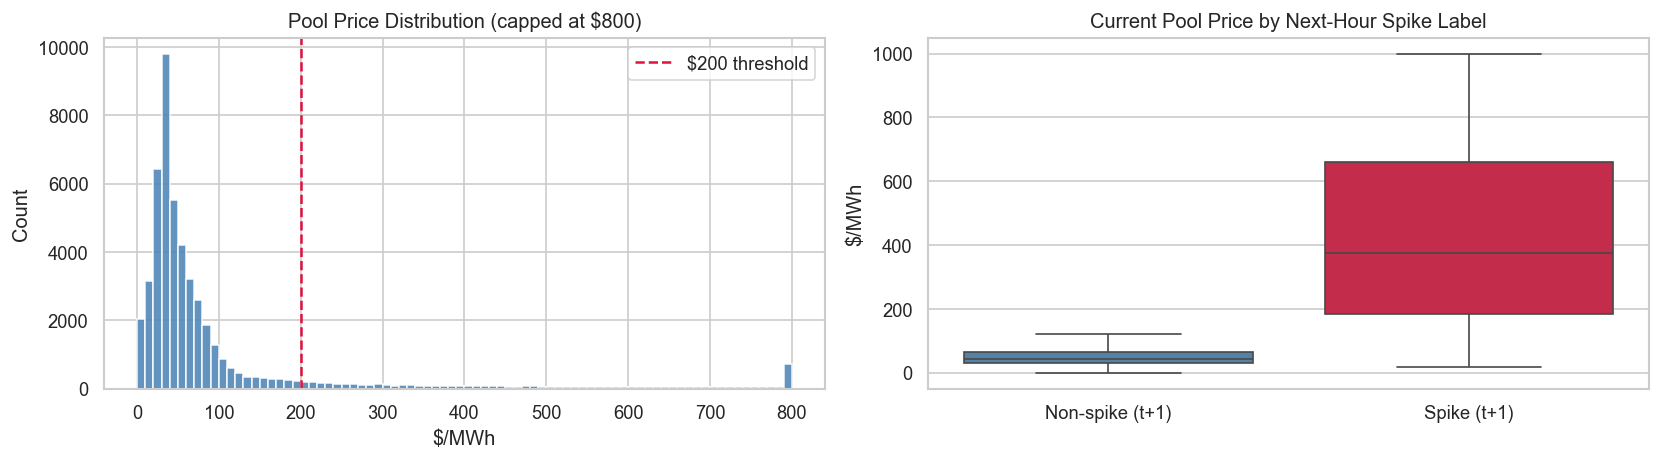

count    48839.000000
mean        95.043037
std        153.980565
min          0.000000
50%         45.410000
90%        199.282000
95%        431.057000
99%        843.849800
99.9%      999.990000
max        999.990000
Name: ACTUAL_POOL_PRICE, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram (capped at 800 for visibility)
cap = df["ACTUAL_POOL_PRICE"].clip(upper=800)
axes[0].hist(cap, bins=80, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(200, color="crimson", ls="--", lw=1.5, label="$200 threshold")
axes[0].set_title("Pool Price Distribution (capped at $800)")
axes[0].set_xlabel("$/MWh")
axes[0].set_ylabel("Count")
axes[0].legend()

# Box plot by spike label
spike_label = df[TARGET].map({0: "Non-spike (t+1)", 1: "Spike (t+1)"})
plot_df = df[["ACTUAL_POOL_PRICE"]].assign(label=spike_label)
sns.boxplot(data=plot_df, x="label", y="ACTUAL_POOL_PRICE", ax=axes[1],
            palette=["steelblue", "crimson"], showfliers=False)
axes[1].set_title("Current Pool Price by Next-Hour Spike Label")
axes[1].set_xlabel("")
axes[1].set_ylabel("$/MWh")

plt.tight_layout()
plt.show()

print(df["ACTUAL_POOL_PRICE"].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]))

## 4. Average Price Heatmap — Hour of Day × Month

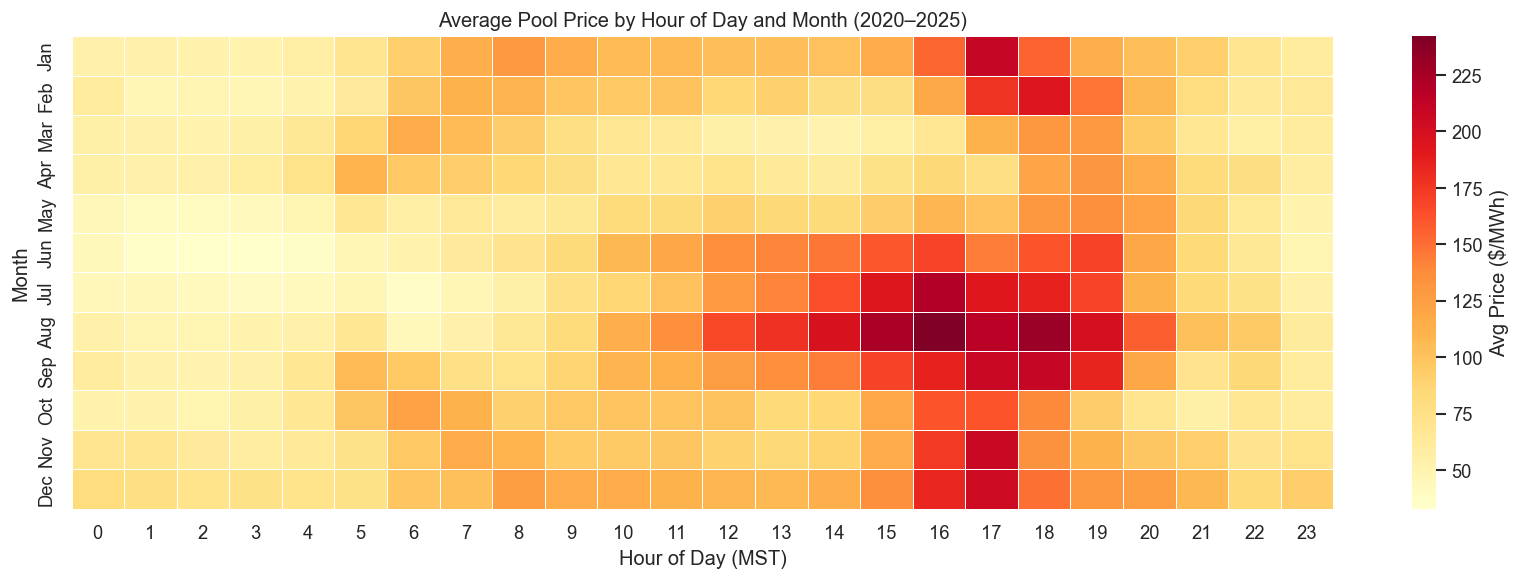

In [14]:
pivot = (df.groupby(["month", "hour_of_day"])["ACTUAL_POOL_PRICE"]
           .mean()
           .unstack("hour_of_day"))
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, linewidths=0.3,
            cbar_kws={"label": "Avg Price ($/MWh)"},
            yticklabels=month_labels)
ax.set_title("Average Pool Price by Hour of Day and Month (2020\u20132025)")
ax.set_xlabel("Hour of Day (MST)")
ax.set_ylabel("Month")
plt.tight_layout()
plt.show()

## 5. Generation by Fuel Type Over Time

ValueError: When stacked is True, each column must be either all positive or all negative. Column 'dual_fuel_total' contains both positive and negative values

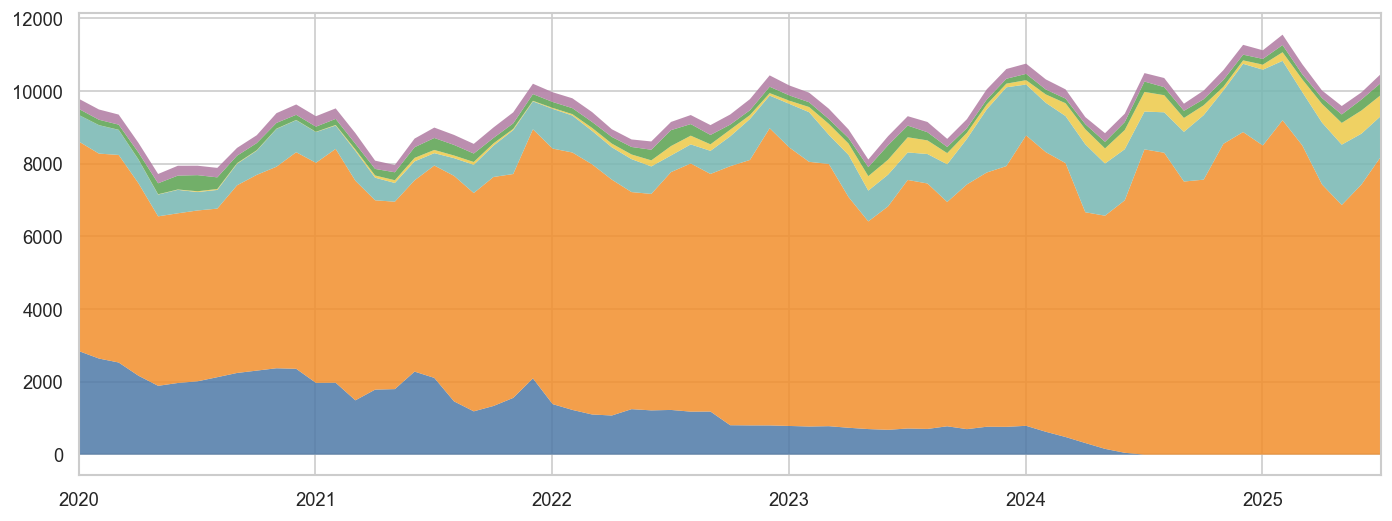

In [15]:
fuel_cols = ["coal_total", "gas_total", "wind_total", "solar_total",
             "hydro_total", "other_total", "dual_fuel_total", "energy_storage_total"]
colors = ["#4e79a7","#f28e2b","#76b7b2","#edc948","#59a14f","#b07aa1","#ff9da7","#9c755f"]

monthly_gen = (df.set_index("datetime")[fuel_cols]
                 .resample("ME").mean())

fig, ax = plt.subplots(figsize=(14, 5))
monthly_gen.plot.area(ax=ax, color=colors, alpha=0.85, linewidth=0)
ax.set_title("Monthly Average Generation by Fuel Type (MW)")
ax.set_ylabel("MW")
ax.set_xlabel("")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 6. Spike Rate by Hour and Month

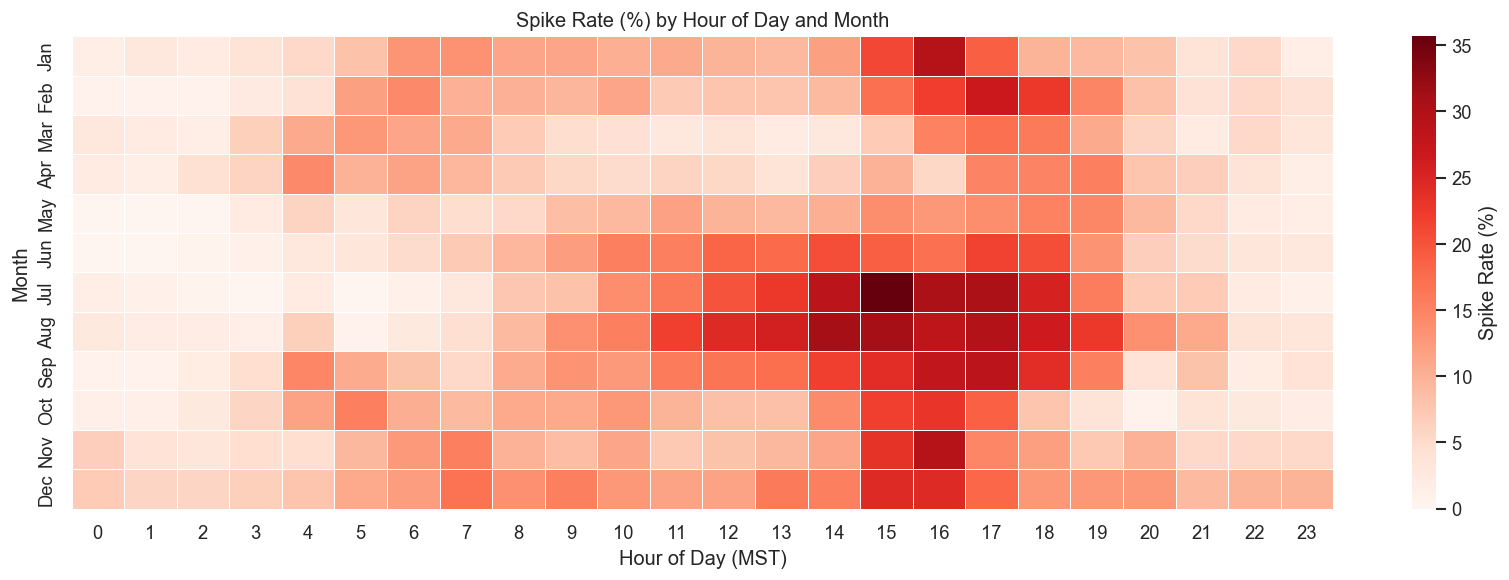

In [16]:
spike_pivot = (df.groupby(["month", "hour_of_day"])[TARGET]
                 .mean()
                 .unstack("hour_of_day"))

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(spike_pivot * 100, cmap="Reds", ax=ax, linewidths=0.3,
            cbar_kws={"label": "Spike Rate (%)"},
            yticklabels=month_labels, fmt=".1f", annot=False)
ax.set_title("Spike Rate (%) by Hour of Day and Month")
ax.set_xlabel("Hour of Day (MST)")
ax.set_ylabel("Month")
plt.tight_layout()
plt.show()

## 7. Correlation Matrix — Key Features

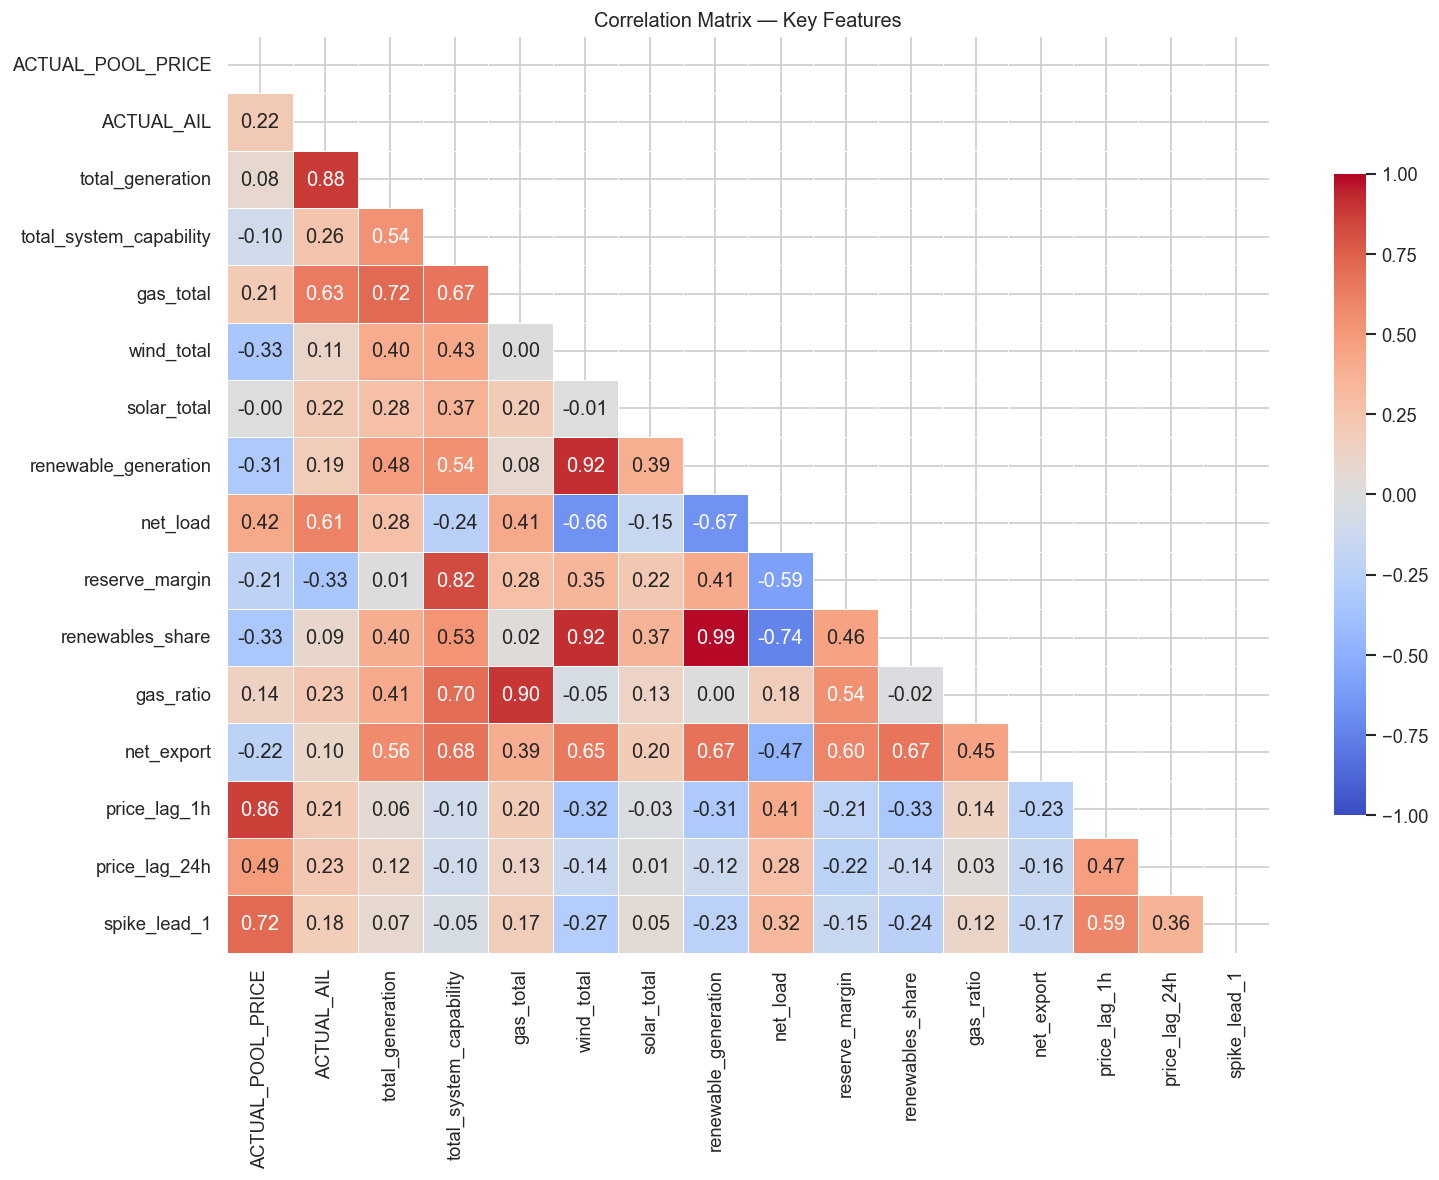

In [17]:
key_features = [
    "ACTUAL_POOL_PRICE", "ACTUAL_AIL", "total_generation",
    "total_system_capability", "gas_total", "wind_total", "solar_total",
    "renewable_generation", "net_load", "reserve_margin",
    "renewables_share", "gas_ratio", "net_export",
    "price_lag_1h", "price_lag_24h", TARGET
]
corr = df[key_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, annot=True,
            fmt=".2f", linewidths=0.4, ax=ax, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.7})
ax.set_title("Correlation Matrix \u2014 Key Features")
plt.tight_layout()
plt.show()

## 8. Spike vs Non-Spike System Conditions

C:\Users\Carolmon\AppData\Local\Temp\ipykernel_22680\743463858.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="label", y=col, ax=axes[i],
C:\Users\Carolmon\AppData\Local\Temp\ipykernel_22680\743463858.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="label", y=col, ax=axes[i],
C:\Users\Carolmon\AppData\Local\Temp\ipykernel_22680\743463858.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="label", y=col, ax=axes[i],
C:\Users\Carolmon\AppData\Local\Temp\ipykernel_22680\743463858.py:1

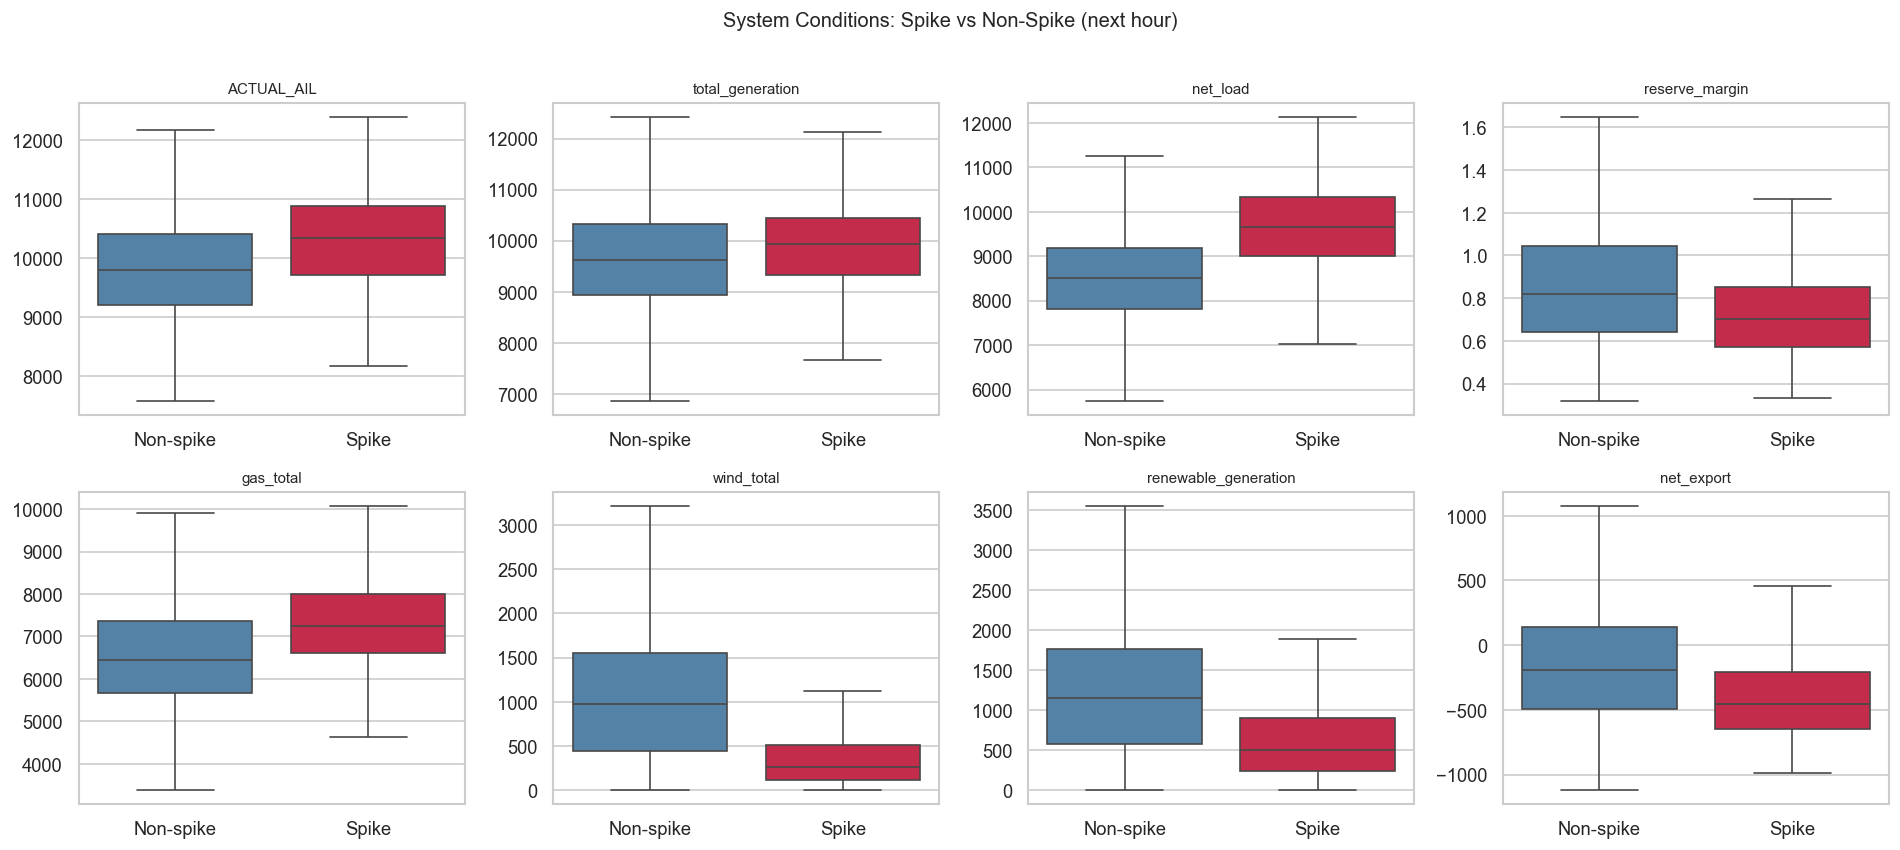

In [18]:
compare_cols = [
    "ACTUAL_AIL", "total_generation", "net_load",
    "reserve_margin", "gas_total", "wind_total",
    "renewable_generation", "net_export",
]
df_plot = df[compare_cols + [TARGET]].copy()
df_plot["label"] = df_plot[TARGET].map({0: "Non-spike", 1: "Spike"})

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(compare_cols):
    sns.boxplot(data=df_plot, x="label", y=col, ax=axes[i],
                palette={"Non-spike": "steelblue", "Spike": "crimson"},
                showfliers=False)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
plt.suptitle("System Conditions: Spike vs Non-Spike (next hour)", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## 9. Alberta Internal Load — Weekly Seasonality

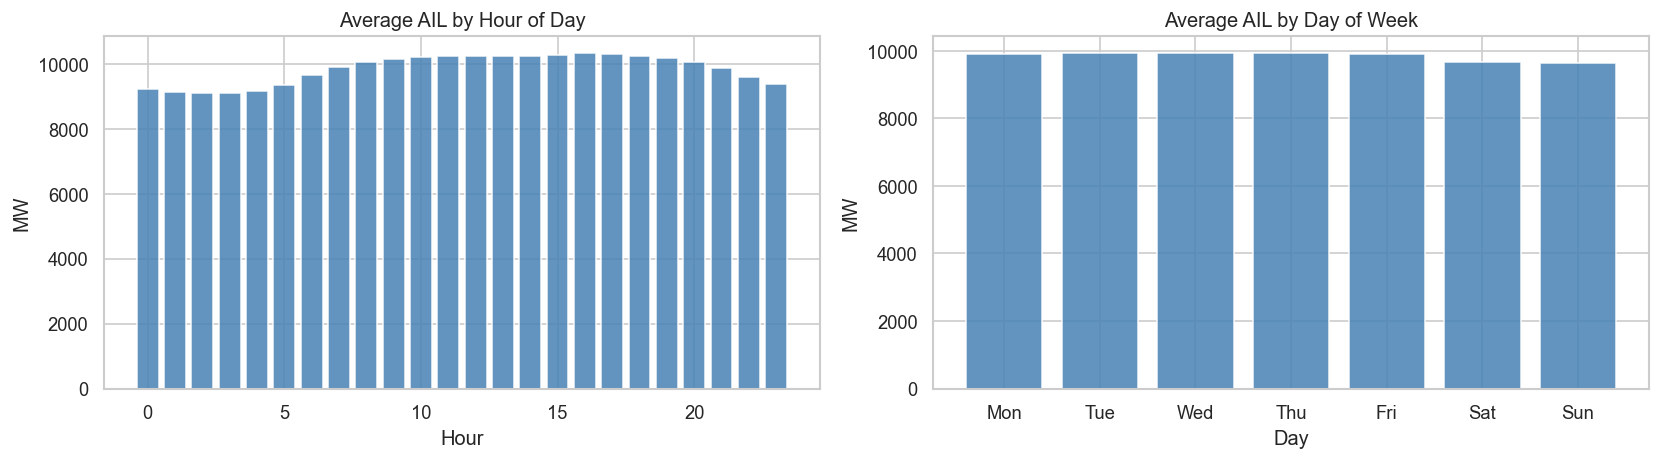

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# By hour of day
ail_by_hour = df.groupby("hour_of_day")["ACTUAL_AIL"].mean()
axes[0].bar(ail_by_hour.index, ail_by_hour.values, color="steelblue", alpha=0.85)
axes[0].set_title("Average AIL by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("MW")

# By day of week
ail_by_dow = df.groupby("day_of_week")["ACTUAL_AIL"].mean()
day_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
axes[1].bar(day_names, ail_by_dow.values, color="steelblue", alpha=0.85)
axes[1].set_title("Average AIL by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("MW")

plt.tight_layout()
plt.show()

## 10. Summary Statistics

In [20]:
print("=== Key Summary Statistics ===\n")
print(f"Total observations     : {len(df):,}")
print(f"Spike hours (t+1=1)    : {df[TARGET].sum():,}  ({df[TARGET].mean():.2%})")
print(f"Date range             : {df['datetime'].min().date()} \u2192 {df['datetime'].max().date()}")
print()

print("Pool price percentiles:")
print(df["ACTUAL_POOL_PRICE"].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999]).round(2))
print()

print("Spike hours by year:")
print(df.groupby(df["datetime"].dt.year)[TARGET].agg(["sum","mean"])
        .rename(columns={"sum":"spike_count","mean":"spike_rate"})
        .assign(spike_rate=lambda x: x["spike_rate"].map("{:.2%}".format)))

=== Key Summary Statistics ===

Total observations     : 48,839
Spike hours (t+1=1)    : 4,858  (9.95%)
Date range             : 2020-01-02 → 2025-07-30

Pool price percentiles:
0.500     45.41
0.750     78.83
0.900    199.28
0.950    431.06
0.990    843.85
0.999    999.99
Name: ACTUAL_POOL_PRICE, dtype: float64

Spike hours by year:
          spike_count spike_rate
datetime                        
2020              189      2.16%
2021              870      9.93%
2022             1659     18.94%
2023             1541     17.59%
2024              501      5.72%
2025               98      1.94%
